In [108]:
print("shiva")


shiva


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

In [110]:
df = pd.read_csv(r"C:\Users\Pooja\Downloads\CARBON_PREDICTION\owid-co2-data.csv")   # change name if needed


print("Original Shape:", df.shape)
df.head()

Original Shape: (25989, 60)


,iso_code,country,year,co2,co2_per_capita,trade_co2,cement_co2,cement_co2_per_capita,coal_co2,coal_co2_per_capita,...,ghg_excluding_lucf_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,AFG,Afghanistan,1949,0.015,0.002,NaN,NaN,NaN,0.015,0.002,...,NaN,NaN,NaN,NaN,NaN,7624058.0,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1950,0.084,0.011,NaN,NaN,NaN,0.021,0.003,...,NaN,NaN,NaN,NaN,NaN,7752117.0,9.421400e+09,NaN,NaN,NaN
2,AFG,Afghanistan,1951,0.092,0.012,NaN,NaN,NaN,0.026,0.003,...,NaN,NaN,NaN,NaN,NaN,7840151.0,9.692280e+09,NaN,NaN,NaN
3,AFG,Afghanistan,1952,0.092,0.012,NaN,NaN,NaN,0.032,0.004,...,NaN,NaN,NaN,NaN,NaN,7935996.0,1.001733e+10,NaN,NaN,NaN
4,AFG,Afghanistan,1953,0.106,0.013,NaN,NaN,NaN,0.038,0.005,...,NaN,NaN,NaN,NaN,NaN,8039684.0,1.063052e+10,NaN,NaN,NaN


In [111]:
df = df[df["country"] == "India"]

print("After Country Filter:", df.shape)

After Country Filter: (163, 60)


In [112]:
features = [
    "year",
    "population",
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp"
]

target = "co2"

df_model = df[["year"] + features + [target]].copy()

print("Selected Columns Shape:", df_model.shape)
df_model.head()

Selected Columns Shape: (163, 8)


,year,year,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2
11115,1858,1858,243455595.0,NaN,NaN,NaN,NaN,0.395
11116,1859,1859,244429232.0,NaN,NaN,NaN,NaN,0.637
11117,1860,1860,245406706.0,NaN,NaN,NaN,NaN,0.644
11118,1861,1861,246388032.0,2.196186e+11,NaN,NaN,NaN,0.498
11119,1862,1862,247373226.0,NaN,NaN,NaN,NaN,0.551


In [113]:
df_model = df_model.dropna(subset=[target])
df_model = df_model.fillna(0)

print("After Cleaning:", df_model.shape)

After Cleaning: (152, 8)


In [114]:
X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (152, 7)
y shape: (152,)


In [115]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (121, 7)
Testing size: (31, 7)


In [116]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [117]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression Results (Chronological Split):")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Linear Regression Results (Chronological Split):
MAE: 324.5113214867616
RMSE: 414.9561358785131
R2 Score: 0.604430230565727


In [118]:
# ==========================================
# Random Forest Regressor
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results (Chronological Split):")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results (Chronological Split):
MAE: 925.107335161291
RMSE: 1153.044865476686
R2 Score: -2.0542960111934314


In [119]:
# ==========================================
# Redefine Features (Add Year)
# ==========================================

features = [
    "year",
    "population",
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp"
]

target = "co2"

# Rebuild modeling dataframe
df_model = df[features + [target]].copy()

# Remove rows where target missing
df_model = df_model.dropna(subset=[target])

# Fill other missing values
df_model = df_model.fillna(0)

# Sort chronologically
df_model = df_model.sort_values(by="year")

print("Final Dataset Shape:", df_model.shape)
df_model.head()

Final Dataset Shape: (152, 7)


,year,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2
11115,1858,243455595.0,0.000000e+00,0.0,0.0,0.0,0.395
11116,1859,244429232.0,0.000000e+00,0.0,0.0,0.0,0.637
11117,1860,245406706.0,0.000000e+00,0.0,0.0,0.0,0.644
11118,1861,246388032.0,2.196186e+11,0.0,0.0,0.0,0.498
11119,1862,247373226.0,0.000000e+00,0.0,0.0,0.0,0.551


In [120]:
# ==========================================
# Define X and y
# ==========================================

X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (152, 6)
y shape: (152,)


In [121]:
# ==========================================
# Chronological Train-Test Split
# ==========================================

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (121, 6)
Testing size: (31, 6)


In [122]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [123]:
# ==========================================
# Linear Regression (With Year)
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results (With Year):")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results (With Year):
MAE: 324.51132148676095
RMSE: 414.95613587851255
R2 Score: 0.6044302305657281


In [124]:
# ==========================================
# Random Forest (With Year)
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results (With Year):")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results (With Year):
MAE: 929.8971917204309
RMSE: 1159.6896317128642
R2 Score: -2.089600034247131


In [125]:
# ==========================================
# Get Latest Year Data
# ==========================================

latest_data = df_model.iloc[-1:].copy()

print("Latest Year:", latest_data["year"].values[0])
latest_data

Latest Year: 2020


,year,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2
11277,2020,1.380004e+09,0.0,8884.38,6437.936,0.0,2441.792


In [126]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Pooja\Downloads\CARBON_PREDICTION\owid-co2-data.csv")  # change filename if needed
print("Original Shape:", df.shape)
df.head()

Original Shape: (25989, 60)


,iso_code,country,year,co2,co2_per_capita,trade_co2,cement_co2,cement_co2_per_capita,coal_co2,coal_co2_per_capita,...,ghg_excluding_lucf_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,AFG,Afghanistan,1949,0.015,0.002,NaN,NaN,NaN,0.015,0.002,...,NaN,NaN,NaN,NaN,NaN,7624058.0,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1950,0.084,0.011,NaN,NaN,NaN,0.021,0.003,...,NaN,NaN,NaN,NaN,NaN,7752117.0,9.421400e+09,NaN,NaN,NaN
2,AFG,Afghanistan,1951,0.092,0.012,NaN,NaN,NaN,0.026,0.003,...,NaN,NaN,NaN,NaN,NaN,7840151.0,9.692280e+09,NaN,NaN,NaN
3,AFG,Afghanistan,1952,0.092,0.012,NaN,NaN,NaN,0.032,0.004,...,NaN,NaN,NaN,NaN,NaN,7935996.0,1.001733e+10,NaN,NaN,NaN
4,AFG,Afghanistan,1953,0.106,0.013,NaN,NaN,NaN,0.038,0.005,...,NaN,NaN,NaN,NaN,NaN,8039684.0,1.063052e+10,NaN,NaN,NaN


In [127]:
df = df[df["country"] == "India"]
print("After Country Filter:", df.shape)

After Country Filter: (163, 60)


In [128]:
features = [
    "year",
    "population",
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp"
]

target = "co2"

df_model = df[features + [target]].copy()
print("Selected Shape:", df_model.shape)
df_model.head()

Selected Shape: (163, 7)


,year,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2
11115,1858,243455595.0,NaN,NaN,NaN,NaN,0.395
11116,1859,244429232.0,NaN,NaN,NaN,NaN,0.637
11117,1860,245406706.0,NaN,NaN,NaN,NaN,0.644
11118,1861,246388032.0,2.196186e+11,NaN,NaN,NaN,0.498
11119,1862,247373226.0,NaN,NaN,NaN,NaN,0.551


In [129]:
# Drop rows where target missing
df_model = df_model.dropna(subset=[target])

# Sort before forward fill
df_model = df_model.sort_values(by="year")

# Forward fill missing economic values
df_model = df_model.fillna(method="ffill")

print("After Cleaning:", df_model.shape)
df_model.tail()

After Cleaning: (152, 7)


C:\Users\Pooja\AppData\Local\Temp\ipykernel_12208\2505764554.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_model = df_model.fillna(method="ffill")


,year,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2
11273,2016,1.324517e+09,7.767449e+12,8320.578,6281.970,1.071,2382.223
11274,2017,1.338677e+09,8.275647e+12,8649.976,6461.587,1.045,2433.856
11275,2018,1.352642e+09,8.835758e+12,9204.848,6805.087,1.042,2599.806
11276,2019,1.366418e+09,8.835758e+12,9414.266,6889.742,1.042,2625.968
11277,2020,1.380004e+09,8.835758e+12,8884.380,6437.936,1.042,2441.792


In [130]:
X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (152, 6)
y shape: (152,)


In [131]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (121, 6)
Testing size: (31, 6)


In [132]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [133]:
# ==========================================
# Proper Missing Value Handling
# ==========================================

# Drop rows where target is missing
df_model = df_model.dropna(subset=[target])

# Sort by year first
df_model = df_model.sort_values(by="year")

# Forward fill
df_model = df_model.ffill()

# Backward fill (to handle starting NaNs)
df_model = df_model.bfill()

# Final safety check
print("Remaining NaNs:\n", df_model.isnull().sum())

Remaining NaNs:
 year                          0
population                    0
gdp                           0
primary_energy_consumption    0
energy_per_capita             0
energy_per_gdp                0
co2                           0
dtype: int64


In [134]:
X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (152, 6)
y shape: (152,)


In [135]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (121, 6)
Testing size: (31, 6)


In [136]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [137]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Linear Regression Results:
MAE: 109.5872336204963
RMSE: 130.394992208289
R2 Score: 0.9609392535822265


In [138]:
latest_data = df_model.iloc[-1:].copy()

print("Latest Year:", latest_data["year"].values[0])
latest_data

Latest Year: 2020


,year,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,co2
11277,2020,1.380004e+09,8.835758e+12,8884.38,6437.936,1.042,2441.792


In [139]:
X_latest = latest_data[features]
X_latest_scaled = scaler.transform(X_latest)

current_prediction = lr.predict(X_latest_scaled)

print("Predicted Current CO2:", current_prediction[0])

Predicted Current CO2: 2382.1330861264255


In [140]:
optimized_data = latest_data.copy()

optimized_data["energy_per_capita"] *= 0.90
optimized_data["energy_per_gdp"] *= 0.92

X_opt = optimized_data[features]
X_opt_scaled = scaler.transform(X_opt)

optimized_prediction = lr.predict(X_opt_scaled)

print("Optimized CO2 Prediction:", optimized_prediction[0])

Optimized CO2 Prediction: 2406.8709389133865


In [141]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
})

coef_df

,Feature,Coefficient
0,year,-6.594338
1,population,60.650714
2,gdp,44.945911
3,primary_energy_consumption,29.004262
4,energy_per_capita,-5.765280
5,energy_per_gdp,-6.478706


In [142]:
# ==========================================
# Correct Optimization Scenario
# ==========================================

optimized_data = latest_data.copy()

# Reduce primary energy consumption by 10%
optimized_data["primary_energy_consumption"] *= 0.90

X_opt = optimized_data[features]
X_opt_scaled = scaler.transform(X_opt)

optimized_prediction = lr.predict(X_opt_scaled)

print("Current CO2:", current_prediction[0])
print("Optimized CO2:", optimized_prediction[0])

reduction = current_prediction[0] - optimized_prediction[0]
reduction_percent = (reduction / current_prediction[0]) * 100

print("Emission Reduction:", reduction)
print("Emission Reduction (%):", reduction_percent)

Current CO2: 2382.1330861264255
Optimized CO2: 2293.0314812259307
Emission Reduction: 89.10160490049475
Emission Reduction (%): 3.7404125495516465


In [143]:
# ==========================================
# Multi-Scenario Energy Reduction Simulation
# ==========================================

reduction_levels = [0, 5, 10, 15, 20, 25, 30]

co2_predictions = []

for r in reduction_levels:
    
    scenario_data = latest_data.copy()
    
    # Reduce primary energy consumption
    scenario_data["primary_energy_consumption"] *= (1 - r/100)
    
    X_scenario = scenario_data[features]
    X_scenario_scaled = scaler.transform(X_scenario)
    
    prediction = lr.predict(X_scenario_scaled)[0]
    
    co2_predictions.append(prediction)

co2_predictions

[2382.1330861264255,
 2337.582283676178,
 2293.0314812259307,
 2248.4806787756834,
 2203.929876325436,
 2159.3790738751886,
 2114.828271424941]

In [144]:
# ==========================================
# Calculate % CO2 Reduction
# ==========================================

base_co2 = co2_predictions[0]

co2_reduction_percent = [
    ((base_co2 - val) / base_co2) * 100
    for val in co2_predictions
]

list(zip(reduction_levels, co2_reduction_percent))

[(0, 0.0),
 (5, 1.8702062747758232),
 (10, 3.7404125495516465),
 (15, 5.610618824327469),
 (20, 7.480825099103293),
 (25, 9.351031373879117),
 (30, 11.221237648654958)]

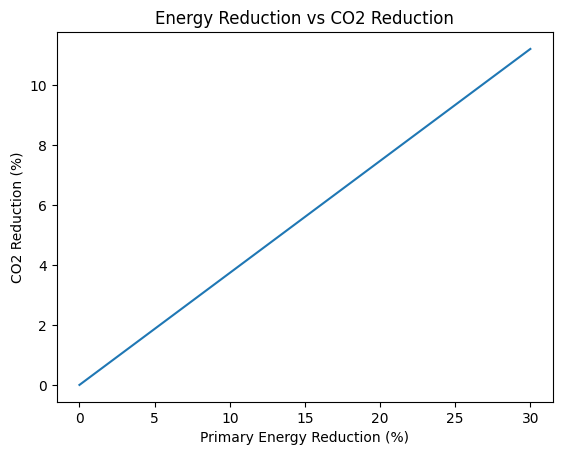

In [145]:
# ==========================================
# Visualization
# ==========================================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(reduction_levels, co2_reduction_percent)
plt.xlabel("Primary Energy Reduction (%)")
plt.ylabel("CO2 Reduction (%)")
plt.title("Energy Reduction vs CO2 Reduction")
plt.show()

In [146]:
import joblib

joblib.dump(lr, "co2_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [147]:
from sklearn.metrics import r2_score

train_pred = lr.predict(X_train_scaled)
test_pred = lr.predict(X_test_scaled)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.9929760144514118
Test R2: 0.9609392535822265


In [148]:
sample = df[df["year"] == 2019]  # or whichever year you used
print("Actual CO2:", sample["co2"].values[0])

Actual CO2: 2625.968


In [149]:
print(df["co2"].min())
print(df["co2"].max())

0.395
2625.968


In [150]:
print(features)

['year', 'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp']


In [151]:
import joblib

joblib.dump(lr, "co2_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Updated model saved.")

Updated model saved.


In [152]:
scaler.fit(X_train)

StandardScaler()

In [153]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [154]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.9929760144514118
Test R2: 0.9609392535822265


In [155]:
import joblib

joblib.dump(model, "co2_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Final updated model saved successfully.")

Final updated model saved successfully.


In [157]:
sample[features].isna().sum()

year                          0
population                    0
gdp                           1
primary_energy_consumption    0
energy_per_capita             0
energy_per_gdp                1
dtype: int64

In [158]:
clean_df = df.dropna()

print(clean_df.tail())

Empty DataFrame
Columns: [iso_code, country, year, co2, co2_per_capita, trade_co2, cement_co2, cement_co2_per_capita, coal_co2, coal_co2_per_capita, flaring_co2, flaring_co2_per_capita, gas_co2, gas_co2_per_capita, oil_co2, oil_co2_per_capita, other_industry_co2, other_co2_per_capita, co2_growth_prct, co2_growth_abs, co2_per_gdp, co2_per_unit_energy, consumption_co2, consumption_co2_per_capita, consumption_co2_per_gdp, cumulative_co2, cumulative_cement_co2, cumulative_coal_co2, cumulative_flaring_co2, cumulative_gas_co2, cumulative_oil_co2, cumulative_other_co2, trade_co2_share, share_global_co2, share_global_cement_co2, share_global_coal_co2, share_global_flaring_co2, share_global_gas_co2, share_global_oil_co2, share_global_other_co2, share_global_cumulative_co2, share_global_cumulative_cement_co2, share_global_cumulative_coal_co2, share_global_cumulative_flaring_co2, share_global_cumulative_gas_co2, share_global_cumulative_oil_co2, share_global_cumulative_other_co2, total_ghg, ghg_pe

In [160]:
features = [
    'year',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'energy_per_gdp'
]

model_df = df[features + ['co2']].dropna()

print("Rows after cleaning:", model_df.shape)

Rows after cleaning: (54, 7)


In [161]:
df[features + ['co2']].isna().sum()

year                            0
population                      0
gdp                            26
primary_energy_consumption    107
energy_per_capita             107
energy_per_gdp                109
co2                            11
dtype: int64

In [162]:
print(len(df))

163


In [163]:
# Define improved feature set
features = [
    'year',
    'population',
    'gdp',
    'primary_energy_consumption'
]

# Create clean modeling dataset
model_df = df[features + ['co2']].dropna()

print("Rows after cleaning:", model_df.shape)

Rows after cleaning: (54, 5)


In [164]:
features = [
    'year',
    'population',
    'gdp'
]

model_df = df[features + ['co2']].dropna()

print("Rows after cleaning:", model_df.shape)

Rows after cleaning: (136, 4)


In [165]:
features = ['year', 'population', 'gdp']

model_df = df[features + ['co2']].dropna()
model_df = model_df.sort_values('year')

In [166]:
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df['co2']

X_test = test_df[features]
y_test = test_df['co2']

In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [168]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [169]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test_scaled)

print("Train R2:", model.score(X_train_scaled, y_train))
print("Test R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train R2: 0.9927135974419239
Test R2: 0.9743782153142426
MAE: 71.43466783579544
RMSE: 96.6807788952455


In [170]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']